In [1]:
import collections
import matplotlib.pyplot as plt
from IPython import display
#import itertools as itr
import numpy as np
import math
#from sklearn.metrics import mean_squared_error
#from random import randrange
#from tabulate import tabulate

import torch
from torch import Tensor, nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
#from torch.func import functional_call, vmap, vjp, jvp, grad

#from scipy.linalg import svdvals, norm
#from scipy.special import softmax
#from scipy.optimize import minimize_scalar

from common.const import DATASET_PATH
from common.util import *
from common.ffn_model.minst.ffn_minst_util import MetaData
from common.optimise import OptimiserEtaSoftmaxArmihoNorm2Base, reduce_to_active

from torchvision.datasets import CIFAR10
from torchvision import transforms

import logging

d:\Projects-my\ml\Ml-readinggroup\Roberts_Yaida\chapterInf\common\optimise.py:50: SyntaxWarning: invalid escape sequence '\i'
  '''


In [2]:
logging.basicConfig(filename="log_convcrity_cifar10_epochsd.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s")
#                datefmt="%m/%d/%Y %I:%M:%S")


#### CIFAR10 dataset

In [3]:
# Convert from PIL to torch.Tensort
# and normalize each pixel from [0, 255] range to [0.0, 1.0]
base_transforms = transforms.ToTensor()

# An augmentation that randomly (with a probability equal to 0.5)
# flips the image horizontally
# This will prevent overfitting and make the model more robust
aug_transforms = transforms.RandomHorizontalFlip(p=0.5)

# Gather all transforms together
train_transforms = transforms.Compose([
    base_transforms,
    aug_transforms
])

train_dataset = CIFAR10(root=DATASET_PATH, train=True, download=True, transform=train_transforms)

# Note that we only use `base_transforms` for test dataset
test_dataset = CIFAR10(root=DATASET_PATH, train=False, download=True, transform=base_transforms)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
BATCH_SIZE = 32 #32

# `pin_memory` speed up processing if you use GPU
# `num_workers` also speed up processing since use additional process
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             num_workers=0, pin_memory=True)

In [5]:
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.1
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

INPUT_DIM=32*32 #*3 USING 0.299 ∙ Red + 0.587 ∙ Green + 0.114 ∙ Blue for gray-transform
OUTPUT_DIM = 10 #26  # num of classes

lb, lw = 0.005, 5.0
meta = MetaData(input_dim = INPUT_DIM, output_dim = OUTPUT_DIM, batch_size = BATCH_SIZE, lb = 0.005, lw = 5.0)

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


##### UTILS

In [6]:
HISTORY_NORM1 = collections.defaultdict(list)
HISTORY_NORM2 = collections.defaultdict(list)
HISTORY_ZHS = collections.defaultdict(list)
HISTORY_ZHL = collections.defaultdict(list)
HISTORY_OPTADA = collections.defaultdict(list)
HISTORY_OPTFIX = collections.defaultdict(list)

#### Compare optimisers

In [7]:
def init_weights_copy(net, params):
    net.init_linear_zeros(net.conv1, True)
    net.init_linear_zeros(net.conv2, True)
    net.init_linear_zeros(net.conv3, True)
    net.init_linear_zeros(net.conv4, True)
    net.init_linear_zeros(net.linear5, True)
    net.init_linear_zeros(net.linear6, True)
    with torch.no_grad():
        net.conv1.weight += torch.from_numpy(params['0.weight'])
        net.conv1.bias += torch.from_numpy(params['0.bias'])
        net.conv2.weight += torch.from_numpy(params['2.weight'])
        net.conv2.bias += torch.from_numpy(params['2.bias'])
        net.conv3.weight += torch.from_numpy(params['6.weight'])
        net.conv3.bias += torch.from_numpy(params['6.bias'])
        net.conv4.weight += torch.from_numpy(params['8.weight'])
        net.conv4.bias += torch.from_numpy(params['8.bias'])
        net.linear5.weight += torch.from_numpy(params['13.weight'])
        net.linear5.bias += torch.from_numpy(params['13.bias'])
        net.linear6.weight += torch.from_numpy(params['16.weight'])
        net.linear6.bias += torch.from_numpy(params['16.bias']) 

def print_comparison():
    #start_epoch, finish_epoch = 10, 20
    display.clear_output()
    fig, axes = plt.subplots(2, 1, figsize=(12, 16))
    axes[0].set_title('Loss (Cross Entropy)')
    #axes[0].set_xlim(start_epoch-1, finish_epoch)
    #axes[0].plot(HISTORY_NORM1['train_loss'][2:40], color='g', ls='dotted', alpha=.5, label='Train norm1')
    #axes[0].plot(HISTORY_NORM2['train_loss'][2:40], color='b', ls='dotted', alpha=.5, label='Train norm2')
    #axes[0].plot(HISTORY_ZHS['train_loss'][2:40], color='r', ls='dotted', alpha=.5, label='Train Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['train_loss'][2:40], color='orange', ls='dotted', alpha=.5, label='Train Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['train_loss'][2:40], color='brown', ls='dotted', alpha=.5, label='Train direct Zhang-lambda')
    #axes[0].plot(HISTORY_NORM1['test_loss'], color='g', alpha=.5, label='Test norm1')
    axes[0].plot(HISTORY_NORM2['test_loss'], color='b', alpha=.5, label='Test norm2')
    #axes[0].plot(HISTORY_ZHS['test_loss'], color='r', alpha=.5, label='Test Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['test_loss'], color='orange', alpha=.5, label='Test Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['test_loss'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[0].plot(HISTORY_OPTFIX['test_loss'], color='grey', alpha=.5, label='Test Nesterov-fix optimiser')
    axes[0].grid()
    axes[0].legend()
    axes[0].set_xlabel("Epoch (series of gradient descent steps)")
    axes[0].set_ylabel("Loss value")

    axes[1].set_title('Accuracy')
    #axes[1].set_xlim(10, 20)
    #axes[1].plot(HISTORY_NORM1['train_accuracy'][2:40], color='g', alpha=.5, ls='dotted', label='Train norm1')
    #axes[1].plot(HISTORY_NORM2['train_accuracy'][2:40], color='b', alpha=.5, ls='dotted', label='Train norm2')
    #axes[1].plot(HISTORY_ZHS['train_accuracy'][2:40], color='r', alpha=.5, ls='dotted', label='Train Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['train_accuracy'][2:40], color='orange', alpha=.5, ls='dotted', label='Train Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['train_accuracy'][2:40], color='brown', alpha=.5, ls='dotted', label='Train direct Zhang-lambda')
    #axes[1].plot(HISTORY_NORM1['test_accuracy'], color='g', alpha=.5, label='Test norm1')
    axes[1].plot(HISTORY_NORM2['test_accuracy'], color='b', alpha=.5, label='Test norm2')
    #axes[1].plot(HISTORY_ZHS['test_accuracy'], color='r', alpha=.5, label='Test Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['test_accuracy'], color='orange', alpha=.5, label='Test Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['test_accuracy'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[1].plot(HISTORY_OPTFIX['test_accuracy'], color='grey', alpha=.5, label='Test Nesterov-fix optimiser')
    axes[1].grid()
    axes[1].legend()
    axes[1].set_xlabel("Epoch (series of gradient descent steps)")
    axes[1].set_ylabel("Accuracy value")

    #fig.tight_layout()
    #fig.subplots_adjust(top=0.95)
    dummy=fig.suptitle("Comparison for the same FFN-structure for different optimisers")

    plt.show()

#### Reference CNN

In [8]:
def make_model():
    
    model = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25),
        nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25),
        nn.Flatten(),
        nn.Linear(4096, 256),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.5),
        nn.Linear(256, 10)        
    )

    return model

#### Adapted CNN with the same layers

In [9]:
class CIFAR10ReLU(nn.Module):
    def __init__(self):
        super().__init__()
        self.slope_positive = None
        self.slope_negative = None
        self.do_dropout = False

        self.kernel_size_=(3, 3)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=self.kernel_size_, padding='same')
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=self.kernel_size_, padding='same')
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=self.kernel_size_, padding='same')
        self.conv4 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=self.kernel_size_, padding='same')
        self.linear5 = nn.Linear(4096, 256)
        self.linear6 = nn.Linear(256, 10)

    def set_slopes(self, slope_positive = 1.0, slope_negative = 0.25):
        self.slope_positive = slope_positive
        self.slope_negative = slope_negative

    def PReLU(self, input: Tensor) -> Tensor:
        input = torch.where(input >= 0, self.slope_positive * input, self.slope_negative * input)
        return input

    def forward_(self, x):
        return self.forward(x)
    
    def forward(self, x):
        #channels*size*size
        #3*32*32->16*32*32 <padding='same'?>
        h1 = self.PReLU(self.conv1(x))
        #16*32*32->32*32*32->32*16*16 <padding='same'?>
        h2 = F.max_pool2d(self.PReLU(self.conv2(h1)), 2)
        if self.do_dropout:
            h2 = F.dropout(h2, 0.25)
        #32*16*16->32*16*16 <padding='same'?>
        h3 = self.PReLU(self.conv3(h2))
        #32*16*16->64*16*16->64*8*8 <padding='same'?>
        h4 = F.max_pool2d(self.PReLU(self.conv4(h3)), 2)
        if self.do_dropout:
            h4 = F.dropout(h4, 0.25)
        #64*8*8->4096->256
        h4flat = torch.flatten(h4, 1)
        h5 = self.PReLU(self.linear5(h4flat))
        if self.do_dropout:
            h5 = F.dropout(h5, 0.5)
        return self.linear6(h5)
    
    def init_weights(self, cb=0.0, cw=1.0):
        logging.debug("CNN weights initialisation with cb={}, cw={}".format(cb, cw))

        #Weight initialisation as in 2.19, 2.20
        self.cb, self.cw = cb, cw
        kernel_size = self.kernel_size_[0]*self.kernel_size_[1]
        self.init_linear_weights(self.conv1, True, cb, cw/kernel_size)
        self.init_linear_weights(self.conv2, True, cb, cw/kernel_size)
        self.init_linear_weights(self.conv3, True, cb, cw/kernel_size)
        self.init_linear_weights(self.conv4, True, cb, cw/kernel_size)
        self.init_linear_weights(self.linear5, True, cb, cw/self.linear5.in_features)
        self.init_linear_weights(self.linear6, True, cb, cw/self.linear6.in_features)

    @staticmethod
    def init_linear_weights(linear, bias_on, var_b=0.0, var_w=1.0):
        nn.init.normal_(linear.weight, mean = 0., std = math.sqrt(var_w)) #approach via torch
        if bias_on:
            nn.init.normal_(linear.bias, mean = 0., std = math.sqrt(var_b))

    @staticmethod
    def init_linear_zeros(linear, bias_on):
        nn.init.zeros_(linear.weight)
        if bias_on:
            nn.init.zeros_(linear.bias)

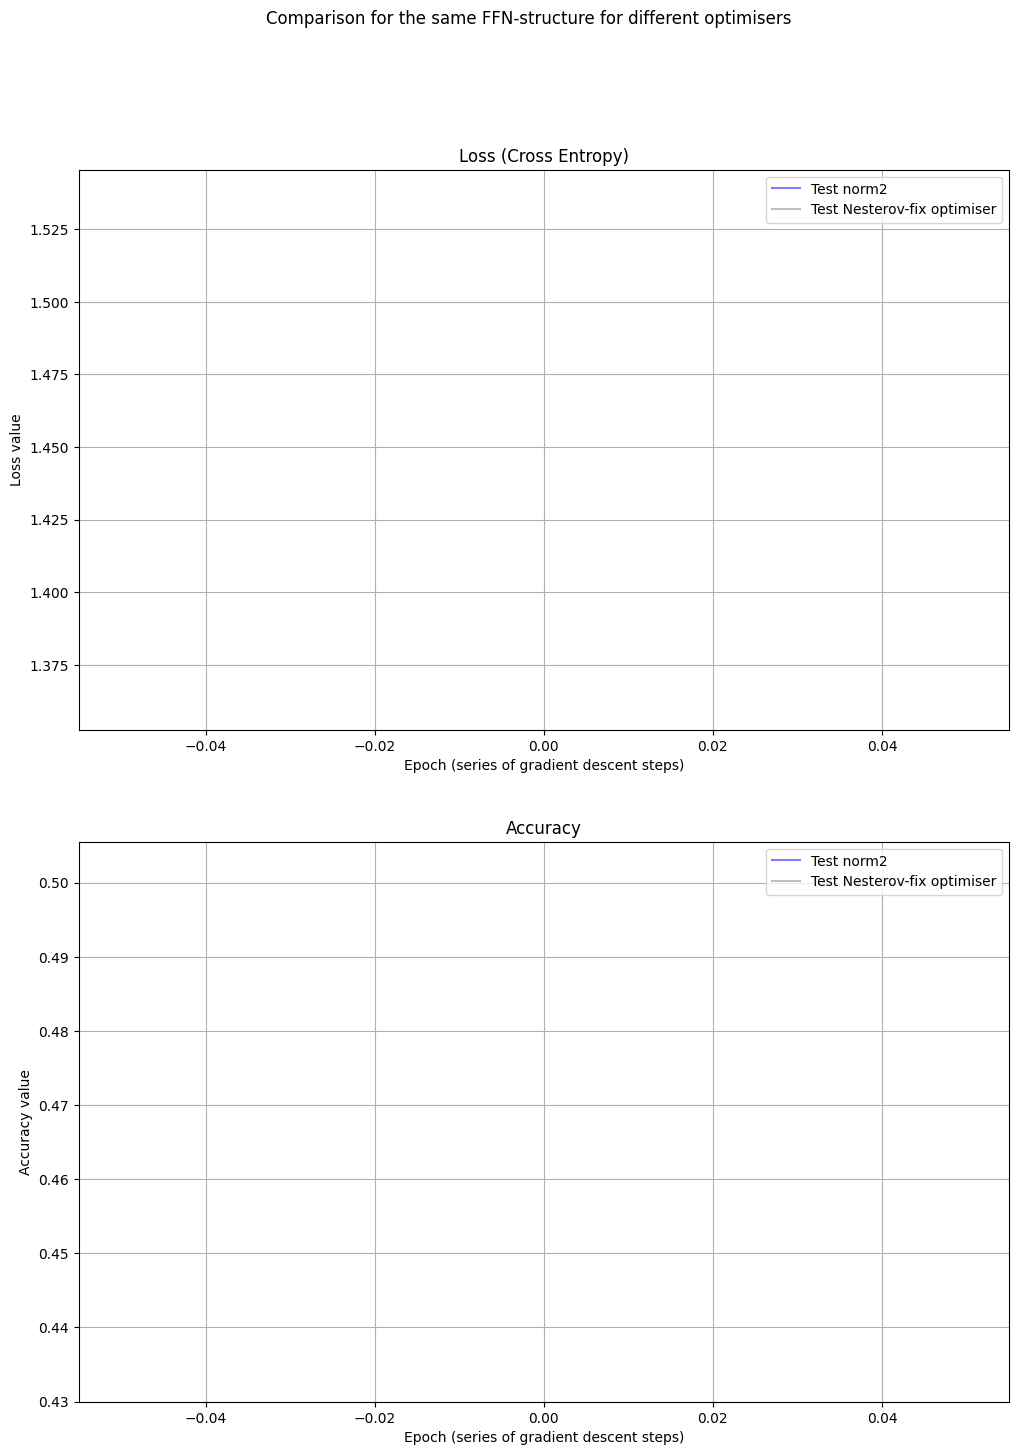

accuracy norm2=[0.4334065495207668], 
accuracy Nesterov-fix=[0.5020966453674122]


In [ ]:
def test_loop(testNet, test_loss_meter, test_accuracy_meter):
    for test_batch in test_dataloader:
        images, labels = test_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            logits = testNet.forward(images)

            zz_logits = np.transpose(logits.detach().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(calculate_accuracy(prediction, labels))

NUM_EPOCH = 20
meta = MetaData(output_dim = OUTPUT_DIM, batch_size = BATCH_SIZE)

DEVICE = torch.device('cpu:0')
HISTORY_OPTIMISER_FIXED = collections.defaultdict(list)
eta_fixed = 0.01

testOptfix = make_model().to(DEVICE)
loss_fnFix = nn.CrossEntropyLoss()
optimizerFix = optim.SGD(testOptfix.parameters(), lr=eta_fixed, momentum=0.9, nesterov=True)
params = {k: v.detach().numpy() for k, v in testOptfix.named_parameters()}

stepCalcSoftmax2 = OptimiserEtaSoftmaxArmihoNorm2Base(meta)
testNorm2S = CIFAR10ReLU()
testNorm2S.set_slopes(slope_plus, slope_minus)
testNorm2S.do_dropout = False
testNorm2S.to(DEVICE)
init_weights_copy(testNorm2S, params)

qu = collections.deque(10*[1.0], 10)
for epoch in range(NUM_EPOCH):
    stepCalcSoftmax2.eta_min = eta_fixed * math.exp(-0.1*epoch)
    optimizerFix.param_groups[0]['lr'] = eta_fixed if epoch < 20 else eta_fixed * 0.1

    testNorm2S.do_dropout = True if epoch > 0 else False
    testOptfix.train()
    iter=0
    for train_batch in train_dataloader:
        images, labels = train_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        iter+=1

        logging.info("##Step with norm2-optim-simple")
        logging.info("##\n --==Epoch={}, iter={}; momentum={}, Nesterov={}, use_ones={}==--"\
                     .format(epoch, iter, 0.9, True, False))
        with torch.no_grad():
            logits = testNorm2S.forward_(images)
            logits_detached = logits.detach().numpy()
            pp = labels_to_softhot(labels, meta.output_dim)
            qq = softmax(np.transpose(logits_detached), axis=(0)) + 1e-8
            qq_active = reduce_to_active(qq, pp)
        logging.info("##\n --==Initial qq for ones: min={}, max={}, avg={}==--"\
                        .format(np.min(qq_active), np.max(qq_active), np.average(qq_active)))
        eta2S, _ = stepCalcSoftmax2.step(testNorm2S, labels, images, momentum=0.9, Nesterov=True, use_ones=False)
        qu.appendleft(eta2S)

        logging.info("##Step with Optim-fix")
        logitsOptfix = testOptfix.forward(images)
        lossOptfix = loss_fnFix(logitsOptfix, labels)
        optimizerFix.zero_grad()
        lossOptfix.backward()
        optimizerFix.step()

    testNorm2S.do_dropout = False
    testOptfix.eval()
    # testing loop
    test_loss2S_meter, test_accuracy2S_meter = AverageMeter(), AverageMeter(),
    test_loop(testNorm2S, test_loss2S_meter, test_accuracy2S_meter)
    HISTORY_NORM2['test_loss'].append(test_loss2S_meter.avg)
    HISTORY_NORM2['test_accuracy'].append(test_accuracy2S_meter.avg) 

    test_lossOptfix_meter, test_accuracyOptfix_meter = AverageMeter(), AverageMeter(),
    test_loop(testOptfix, test_lossOptfix_meter, test_accuracyOptfix_meter)
    HISTORY_OPTFIX['test_loss'].append(test_lossOptfix_meter.avg)
    HISTORY_OPTFIX['test_accuracy'].append(test_accuracyOptfix_meter.avg)    
    
    print_comparison()
    print("accuracy norm2={}, \naccuracy Nesterov-fix={}"\
          .format(HISTORY_NORM2['test_accuracy'], HISTORY_OPTFIX['test_accuracy']))


In [ ]:
print("accuracy norm2={}, \naccuracy Nesterov-fix={}"\
        .format(HISTORY_NORM2['test_accuracy'], HISTORY_OPTFIX['test_accuracy']))

accuracy norm2=[0.5078873801916933, 0.6269968051118211, 0.6812100638977636, 0.7207468051118211], 
accuracy Nesterov-fix=[0.5000998402555911, 0.6293929712460063, 0.6867012779552716, 0.7152555910543131]


In [ ]:
print("accuracy norm2={}, \naccuracy Nesterov-fix={}"\
        .format(HISTORY_NORM2['test_accuracy'], HISTORY_OPTFIX['test_accuracy']))

accuracy norm2=[0.47953274760383385, 0.6089257188498403, 0.6600439297124601], 
accuracy Nesterov-fix=[0.4983027156549521, 0.5933506389776357, 0.6461661341853036]


In [ ]:
print("accuracy norm2={}, \naccuracy Nesterov-fix={}"\
        .format(HISTORY_NORM2['test_accuracy'], HISTORY_OPTFIX['test_accuracy']))

accuracy norm2=[0.49251198083067094, 0.6348841853035144, 0.6946884984025559, 0.7084664536741214, 0.7252396166134185, 0.7440095846645367, 0.7587859424920128, 0.7534944089456869, 0.7639776357827476], 
accuracy Nesterov-fix=[0.5262579872204473, 0.6400758785942492, 0.676417731629393, 0.7180511182108626, 0.733426517571885, 0.7343250798722045, 0.7625798722044729, 0.770167731629393, 0.7761581469648562]
